In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [12]:
# Load Dataset
df = pd.read_csv("car_price.csv")
df

,fuel-type,engine-location,engine-type,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,gas,front,dohc,111,5000,21,27,13495
1,gas,front,dohc,111,5000,21,27,16500
2,gas,front,ohcv,154,5000,19,26,16500
3,gas,front,ohc,102,5500,24,30,13950
4,gas,front,ohc,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...
194,gas,front,ohc,114,5400,23,28,16845
195,gas,front,ohc,160,5300,19,25,19045
196,gas,front,ohcv,134,5500,18,23,21485
197,diesel,front,ohc,106,4800,26,27,22470


In [13]:
# Replace ? with NaN
df.replace("?", np.nan, inplace=True)


In [14]:
# Remove missing values
df.dropna(inplace=True)

In [15]:
# Convert numeric columns
df["horsepower"] = df["horsepower"].astype(float)
df["peak-rpm"] = df["peak-rpm"].astype(float)
df["price"] = df["price"].astype(float)

In [16]:
# Encode categorical columns
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()

df["fuel-type"] = le1.fit_transform(df["fuel-type"])
df["engine-location"] = le2.fit_transform(df["engine-location"])
df["engine-type"] = le3.fit_transform(df["engine-type"])

In [17]:
# Features and Target
X = df[[
    "fuel-type",
    "engine-location",
    "engine-type",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg"
]]

y = df["price"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Train Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

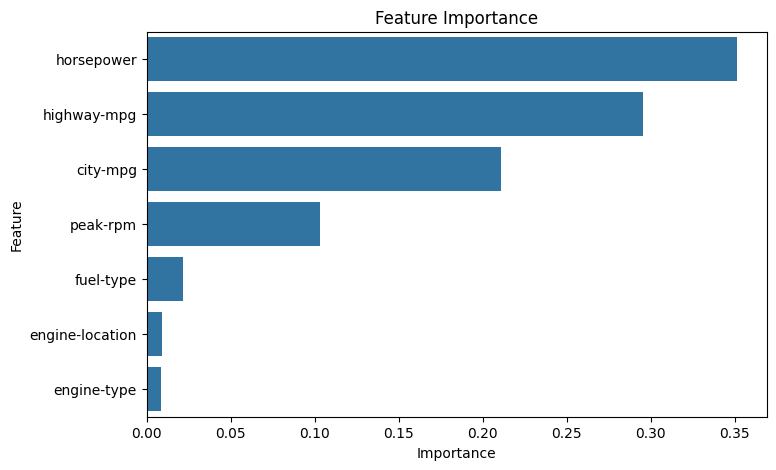

In [19]:
# Feature Importance
importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df
)

plt.title("Feature Importance")
plt.show()

In [22]:
input_data = pd.DataFrame([[
    1, 0, 2, 100, 5000, 25, 30
]], columns=[
    "fuel-type",
    "engine-location",
    "engine-type",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg"
])

prediction = model.predict(input_data)

print("Predicted Price:", prediction[0])

Predicted Price: 10664.750916666668
